# Кредитный скоринг по кредитным историям (Альфа-Банк)

Cоревнование с Kaggle: [alfa-bank-pd-credit-history](https://www.kaggle.com/competitions/alfa-bank-pd-credit-history/data).

## О чём задача
У банка есть клиенты, и у каждого есть кредитная история из БКИ (бюро кредитных историй — там хранится информация обо всех кредитах человека и о том, как он по ним платил). По этой истории надо понять, уйдёт ли клиент в дефолт, то есть перестанет платить по кредиту.

Таргет — `flag`: `1` = был дефолт, `0` = не было. Нужно предсказать не просто «да/нет», а вероятность дефолта. В банках её называют PD (Probability of Default).

## Какие есть данные

1. parquet-файлы, с историей кредитов клиентов
2. csv-файл с таргетом `flag` и  `id` клиента
3. csv-файл c `id` клиента и колонка со скором

В каждой строке около 60 признаков: номер кредита в истории (`rn`), параметры кредита (`pre_*`), флаги просрочек (`is_zero_*`), статусы платежей по месяцам (`enc_paym_0 … enc_paym_24`), категориальные описания кредита (`enc_loans_*`) и пара служебных флагов. Всё это анонимизировано и закодировано целыми числами.

## Главная проблема
Таргет один на клиента, а в данных у клиента много строк (по одной на каждый кредит), причём у всех клиентов их разное количество. Обычная модель так не умеет, ей нужна одна строка на клиента. Поэтому половина работы — это сжать историю клиента в один вектор (агрегаты).

## План
1. Подготовка инструментов
2. Загрузка данных
3. Первый взгляд на данные
4. Таргет и длина истории
5. Качество данных
6. Распределения признаков
7. Связь признаков с таргетом
8. Корреляции
9. Сравнение train и test
10. Сжатие истории до одной строки на клиента
11. Модели
12. Качество модели
13. Submission
14. Выводы

## Шпаргалка по терминам

Сюда буду подглядывать сам. Если термин непонятен дальше по тексту — смотри сюда.

| Термин | Простыми словами |
|---|---|
| **Дефолт** | клиент перестал платить по кредиту (тут это `flag = 1`) |
| **Дисбаланс классов** | дефолтов очень мало по сравнению с «нормальными» клиентами |
| **ROC AUC** | берём случайного дефолтника и случайного нормального клиента. AUC — вероятность, что модель выставила дефолтнику скор **выше**. `0.5` — как монетка, `1.0` — идеал |
| **Gini** | то же самое AUC, только в другой шкале: `Gini = 2·AUC − 1` (так принято в банках) |
| **KS** | насколько далеко друг от друга «разъезжаются» распределения скоров плохих и хороших клиентов |
| **PR AUC** | площадь под кривой precision–recall, хорошо показывает качество на редком классе |
| **Кросс-валидация (CV)** | делим train на K частей: учимся на K−1, проверяемся на оставшейся, и так K раз по кругу |
| **OOF-предсказания** | out-of-fold: предсказания для клиентов, которых модель **не видела** при обучении. По ним честно оцениваем качество |
| **PSI** | показывает, насколько «поплыло» распределение признака между двумя выборками (train и test) |
| **Lift** | во сколько раз доля дефолтов в группе выше, чем в среднем по всем клиентам |
| **Калибровка** | совпадает ли предсказанная вероятность с реальной долей дефолтов |
| **Бустинг** | модель из сотен небольших деревьев, где каждое следующее исправляет ошибки предыдущих |

## 1. Подготовка


In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

DATA_DIR = Path("/content/drive/MyDrive/проекты ML/credit scoring original")
CACHE_DIR = DATA_DIR / "cache"
SUBMISSION_PATH = DATA_DIR / "submission.csv"

assert DATA_DIR.exists(), f"Папка не найдена: {DATA_DIR}"
CACHE_DIR.mkdir(exist_ok=True)
print("Данные:", DATA_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Данные: /content/drive/MyDrive/проекты ML/credit scoring original


### 1.1 Библиотеки
В Colab уже стоят pandas, numpy, matplotlib, seaborn, scikit-learn и LightGBM. Также установим catboost, optuna, shap.

In [ ]:
!pip install -q catboost optuna shap

In [ ]:
import re, gc, glob, time, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy.stats import rankdata
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.calibration import calibration_curve
import lightgbm as lgb

warnings.filterwarnings("ignore")        # чтобы не засорять вывод предупреждениями
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)


pandas 2.2.3 | numpy 2.1.3 | lightgbm 4.6.0


### 1.3 Настройки эксперимента
Можем выбрать свое колиечство файлов train, фолды и настроить learning rate.
 полный прогон на всех данных.



In [ ]:
N_TRAIN_FILES = 6    # сколько train-файлов читать (None = все)
N_FOLDS = 5 # фолдов в кросс-валидации
LGB_LR = 0.04 # learning rate у LightGBM
CB_ITERS = 3000 # макс. число деревьев у CatBoost

RUN_CATBOOST = True    # обучать CatBoost
RUN_OPTUNA = True   # подбор гиперпараметров (долго, по умолчанию выключен)
N_OPTUNA_TRIALS = 20
RUN_SHAP = True    # SHAP-график
USE_CACHE = True    # кэшировать признаки на диск

SEED = 42
np.random.seed(SEED)

print("| N_TRAIN_FILES:", N_TRAIN_FILES, "| N_FOLDS:", N_FOLDS)

FAST_MODE: True | N_TRAIN_FILES: 6 | N_FOLDS: 3


## 2. Загрузка данных
Несколько вспомогательных функций:

* `natural_key` нужен, чтобы файлы `train_data_0.pq, train_data_1.pq, …` шли по номеру: обычная сортировка поставила бы `10` перед `2`.
* `load_part` читает один parquet и уменьшает разрядность чисел (`int64 → int8/int16`, `float64 → float32`).


In [ ]:
def natural_key(path):
    # чтобы train_data_10.pq шёл после train_data_2.pq, а не после train_data_1.pq
    return [int(t) if t.isdigit() else t for t in re.split(r"(\d+)", str(path))]

def downcast(df):
    # уменьшаем разрядность чисел, чтобы данные занимали меньше памяти
    for c in df.columns:
        s = df[c]
        if pd.api.types.is_integer_dtype(s):
            df[c] = pd.to_numeric(s, downcast="integer")
        elif pd.api.types.is_float_dtype(s):
            df[c] = pd.to_numeric(s, downcast="float")
    return df

def load_part(path, columns=None):
    return downcast(pd.read_parquet(path, columns=columns))

train_files_all = sorted(glob.glob(str(DATA_DIR / "train_data" / "*.pq")), key=natural_key)
test_files      = sorted(glob.glob(str(DATA_DIR / "test_data" / "*.pq")), key=natural_key)
assert train_files_all, "train-файлы не найдены"
train_files = train_files_all[:N_TRAIN_FILES] if N_TRAIN_FILES else train_files_all

print(f"train-файлов всего: {len(train_files_all)}, используем: {len(train_files)}")
print(f"test-файлов: {len(test_files)}")
print("Пример имени файла:", Path(train_files[0]).name)

train-файлов всего: 12, используем: 6
test-файлов: 2
Пример имени файла: train_data_0.pq


Теперь таргет. В `train_target.csv` по одной строке на клиента (`id` и `flag`). Делаю `id` индексом, потому что потом удобно сопоставлять таргет с признаками по `id`.

In [ ]:
target = pd.read_csv(DATA_DIR / "train_target.csv").set_index("id")["flag"]
print("Клиентов в train_target:", len(target))
display(target.head())

Клиентов в train_target: 3000000


,flag
id,
0,0
1,0
2,0
3,0
4,0


## 3. Первый взгляд на данные
Из просмотра train файла можно сделать вывод, что уникальных значений мало (≤ 20) и все целые. Скорее всего эти признаки закодированы. Также есть признаки с единственным значением. Еще присутствуют бинарные признаки.  


In [ ]:
df0 = load_part(train_files[0])
print("Размер файла:", df0.shape)
print(f"Место занимает: {df0.memory_usage(deep=True).sum() / 1024**2:.0f} MB")
print("Клиентов в файле:", df0['id'].nunique())
display(df0.head(10))

Размер первого файла: (1974724, 61)
Занимает памяти: 121 MB
Клиентов в файле: 250000


,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
0,0,1,18,9,2,3,16,10,11,3,3,0,2,11,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0
1,0,2,18,9,14,14,12,12,0,3,3,0,2,11,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,4,1,3,4,1,0,0
2,0,3,18,9,4,8,1,11,11,0,5,0,2,8,6,16,5,4,8,1,1,1,1,1,15,2,17,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,4,1,2,3,1,1,1
3,0,4,4,1,9,12,16,7,12,2,3,0,2,4,6,16,5,4,8,0,1,1,1,1,16,2,17,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,1,1,0,0
4,0,5,5,12,15,2,11,12,10,2,3,0,2,4,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0
5,0,6,5,0,11,8,12,11,4,2,3,0,2,4,6,16,5,4,8,1,1,1,1,1,9,5,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,3,4,3,3,3,4,1,2,3,1,0,1
6,0,7,3,9,1,2,12,14,15,5,3,0,2,3,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0
7,0,8,2,9,2,3,12,14,15,5,3,0,2,13,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0
8,0,9,1,9,11,13,14,8,2,5,1,0,2,11,6,16,5,4,8,1,1,1,1,1,1,2,17,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,0,0
9,0,10,7,9,2,10,8,8,16,4,2,0,2,11,6,16,5,4,8,1,1,1,1,1,15,2,17,0,1,1,0,0,0,0,0,0,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,0,0


In [ ]:
def column_summary(df):
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_unique": df.nunique(),
        "min": df.min(),
        "max": df.max(),
        "mean": df.mean().round(3),
        "share_zero": (df == 0).mean().round(3),
        "n_missing": df.isna().sum(),
    })

summary = column_summary(df0)
display(summary)

,dtype,n_unique,min,max,mean,share_zero,n_missing
id,int32,250000,0,249999,125946.473,0.000,0
rn,int8,51,1,51,6.537,0.000,0
pre_since_opened,int8,20,0,19,9.271,0.056,0
pre_since_confirmed,int8,18,0,17,8.330,0.041,0
pre_pterm,int8,18,0,17,8.299,0.039,0
...,...,...,...,...,...,...,...
enc_loans_credit_status,int8,7,0,6,2.695,0.000,0
enc_loans_credit_type,int8,6,0,5,3.354,0.022,0
enc_loans_account_cur,int8,4,0,3,1.002,0.001,0
pclose_flag,int8,2,0,1,0.172,0.828,0


### 3.1 Делим признаки на группы
Признаков много, поэтому разложу их по группам по префиксам. С каждой группой потом будем работать по-своему:

| Группа | Как называются | Что это | Как будем агрегировать |
|---|---|---|---|
| Порядковые `ORD_COLS` | `pre_*` | целые коды (похоже на номера корзин), **порядок важен**: больше значит больше | среднее, максимум, минимум, std |
| Бинарные `BIN_COLS` | `is_zero_*`, `pclose_flag`, `fclose_flag` | флаги 0/1 | доля единиц, сумма |
| История платежей `PAYM_COLS` | `enc_paym_0 … enc_paym_24` | статус платежа в каждом из последовательных периодов | среднее по периоду, счётчики значений |
| Категориальные `CAT_COLS` | `enc_loans_*` | тип, статус, валюта кредита, **порядок не важен** | доли каждой категории |
| Служебные | `id`, `rn` | id клиента и номер кредита в истории | ключ группировки и сортировка |

Что значат конкретные числа, мы не знаем (данные зашифрованы). Но деревьям это не мешает: им важен только порядок значений.

In [ ]:
ID_COL, RN_COL = "id", "rn"
ORD_COLS = [c for c in df0.columns if c.startswith("pre_")]
PAYM_COLS = sorted([c for c in df0.columns if c.startswith("enc_paym_")], key=natural_key)
CAT_COLS = [c for c in df0.columns if c.startswith("enc_loans_")]
BIN_COLS = [c for c in df0.columns if c.startswith("is_zero_")] + [c for c in ("pclose_flag", "fclose_flag") if c in df0.columns]
ZERO_LOAN_COLS = [c for c in df0.columns if c.startswith("is_zero_loans")]   # флаги "нет просрочек" по корзинам длительности

feature_cols = ORD_COLS + BIN_COLS + CAT_COLS + PAYM_COLS
unassigned = set(df0.columns) - set(feature_cols) - {ID_COL, RN_COL}

for name, cols in [("Порядковые (pre_*)", ORD_COLS), ("Бинарные", BIN_COLS), ("Категориальные (enc_loans_*)", CAT_COLS),
                   ("История платежей (enc_paym_*)", PAYM_COLS)]:
    print(f"{name:32s} {len(cols):3d} шт.")
print("Не попали ни в одну группу:", unassigned or "—")

Порядковые (pre_*)                20 шт.
Бинарные                          10 шт.
Категориальные (enc_loans_*)       4 шт.
История платежей (enc_paym_*)     25 шт.
Не попали ни в одну группу: —


## 4. Таргет и длина истории

### 4.1 Сколько кредитов у клиентов
Считаю, сколько кредитов у каждого клиента. Читаю только колонку `id`: parquet колоночный, поэтому это быстро и почти не ест память.

Это пригодится дважды: размер истории сам может быть полезным признаком (`n_loans`), и от него зависит, как правильно агрегировать (клиентов с 1 кредитом и с 30 нужно сравнивать по долям и средним, а не по суммам).

In [ ]:
def count_loans(files):
    parts = [load_part(p, columns=[ID_COL])[ID_COL].value_counts(sort=False) for p in files]
    return pd.concat(parts).groupby(level=0).sum().rename("n_loans")

loans_per_client = count_loans(train_files)
eda = loans_per_client.to_frame().join(target.rename("flag"))

print("Клиентов в используемых файлах:", len(eda))
print("Клиентов без таргета:", int(eda["flag"].isna().sum()))
if N_TRAIN_FILES is None:
    print("Клиентов из target без кредитной истории:", len(target.index.difference(loans_per_client.index)))
display(eda["n_loans"].describe(percentiles=[.05, .25, .5, .75, .95, .99]).round(2).to_frame().T)

Клиентов в используемых файлах: 1500000
Клиентов без таргета: 0


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
n_loans,1500000.0,8.33,5.99,1.0,1.0,4.0,7.0,12.0,20.0,26.0,51.0


### 4.2 Баланс классов
Смотрим, какая доля клиентов ушла в дефолт. Обычно это единицы процентов, и из этого следует несколько вещей:

* accuracy тут бесполезна: если всем ответить «дефолта не будет», получим ~97% точности и ноль пользы. Поэтому берём ROC AUC и родственные метрики;
* при разбиении на фолды нужна стратификация, чтобы в каждой части была та же доля дефолтов;
* случайный предсказатель даёт AUC = 0.5, это нижняя планка.

,count,share
flag,,
0,1446678,0.9645
1,53322,0.0355


Доля дефолтов: 0.0355  → дисбаланс примерно 1 : 27


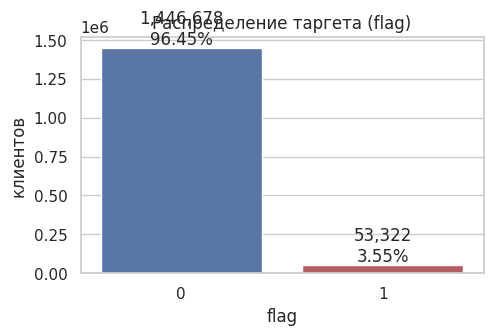

In [ ]:
y_stats = eda["flag"].value_counts().sort_index().rename("count").to_frame()
y_stats["share"] = (y_stats["count"] / y_stats["count"].sum()).round(4)
display(y_stats)
base_rate = eda["flag"].mean()
print(f"Доля дефолтов: {base_rate:.4f}  → дисбаланс примерно 1 : {(1-base_rate)/base_rate:.0f}")

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.barplot(x=y_stats.index.astype(str), y=y_stats["count"], ax=ax, palette=["#4C72B0", "#C44E52"])
for i, (cnt, sh) in enumerate(zip(y_stats["count"], y_stats["share"])):
    ax.text(i, cnt, f"{cnt:,}\n{sh:.2%}", ha="center", va="bottom")
ax.set_title("Распределение таргета (flag)"); ax.set_xlabel("flag"); ax.set_ylabel("клиентов")
plt.tight_layout(); plt.show()

### 4.3 Зависит ли дефолт от длины истории
Группирую клиентов по числу кредитов (всех, у кого больше 30, объединяю в одну группу) и смотрю на два графика: сколько клиентов в каждой группе и какая там доля дефолтов. Пунктир — средняя доля дефолтов по всем.

Если кривая заметно отклоняется от пунктира, значит `n_loans` сам по себе несёт информацию о риске.

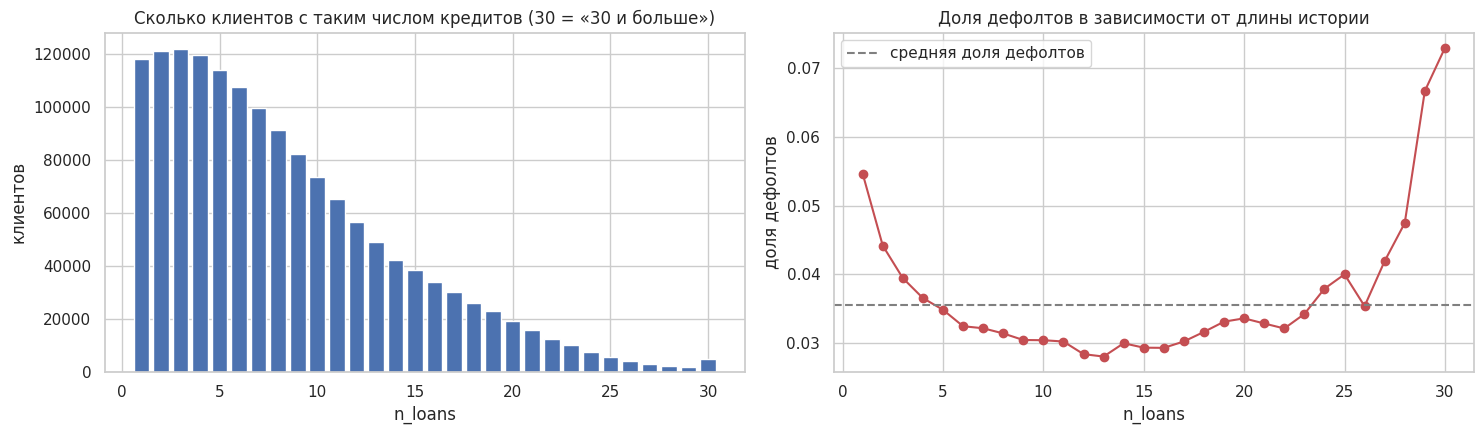

In [ ]:
eda["n_loans_clip"] = eda["n_loans"].clip(upper=30)
rate_by_n = eda.groupby("n_loans_clip")["flag"].agg(["mean", "count"])

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].bar(rate_by_n.index, rate_by_n["count"], color="#4C72B0")
ax[0].set_title("количетво клиентов с разным колиечтвомт кредитов до 30 и «30 и больше»)")
ax[0].set_xlabel("n_loans"); ax[0].set_ylabel("клиентов")
ax[1].plot(rate_by_n.index, rate_by_n["mean"], marker="o", color="#C44E52")
ax[1].axhline(base_rate, ls="--", c="gray", label="средняя доля дефолтов")
ax[1].set_title("Доля дефолтов в зависимости от длины истории"); ax[1].set_xlabel("n_loans"); ax[1].set_ylabel("доля дефолтов"); ax[1].legend()
plt.tight_layout(); plt.show()

## 5. Качество данных

Проверка на пропуски, дубликаты и константы. Дубликаты исказили бы агрегаты, константы бесполезны, а пропуски влияют на выбор модели: LightGBM и CatBoost умеют работать с `NaN` сами, а логистической регрессии придётся что-то подставлять.

In [ ]:
print("Пропусков в df0:", int(df0.isna().sum().sum()))
print("Дубликатов по паре (id, rn):", int(df0.duplicated(subset=[ID_COL, RN_COL]).sum()))
const_cols = summary.index[summary["n_unique"] == 1].tolist()
print("Константные колонки:", const_cols or "—")

# проверим, что rn идёт 1, 2, ..., n без дырок
chk = df0.groupby(ID_COL)[RN_COL].agg(["min", "max", "count"])
print("Доля клиентов, у которых rn = 1..n без пропусков:", round(((chk["min"] == 1) & (chk["max"] == chk["count"])).mean(), 4))

Пропусков в df0: 0
Дубликатов по паре (id, rn): 0
Константные колонки: ['pre_loans_total_overdue']
Доля клиентов, у которых rn = 1..n без пропусков: 1.0


### 5.1 Добавляем таргет к строкам-кредитам
Для разведки добавляю к каждой строке `flag` её клиента. Так можно смотреть, как признаки связаны с дефолтом.



In [ ]:
df0["flag"] = df0[ID_COL].map(target).astype("int8")
print("Строк с таргетом:", len(df0), "| доля дефолтных строк:", round(df0["flag"].mean(), 4))

# множеества значений платежей и категорий
PAYM_LEVELS = sorted(int(v) for v in pd.unique(df0[PAYM_COLS].to_numpy().ravel()))
CAT_LEVELS  = {c: sorted(int(v) for v in df0[c].unique()) for c in CAT_COLS}
print("Значения в enc_paym_*:", PAYM_LEVELS)
print("Сколько уровней у категориальных:", {k: len(v) for k, v in CAT_LEVELS.items()})

Строк с таргетом: 1974724 | доля дефолтных строк: 0.0289
Значения в enc_paym_*: [0, 1, 2, 3, 4]
Сколько уровней у категориальных: {'enc_loans_account_holder_type': 7, 'enc_loans_credit_status': 7, 'enc_loans_credit_type': 6, 'enc_loans_account_cur': 4}


## 6. Распределения признаков

### 6.1 Порядковые признаки `pre_*`
Для каждого признака рисую, как часто встречается каждое значение.


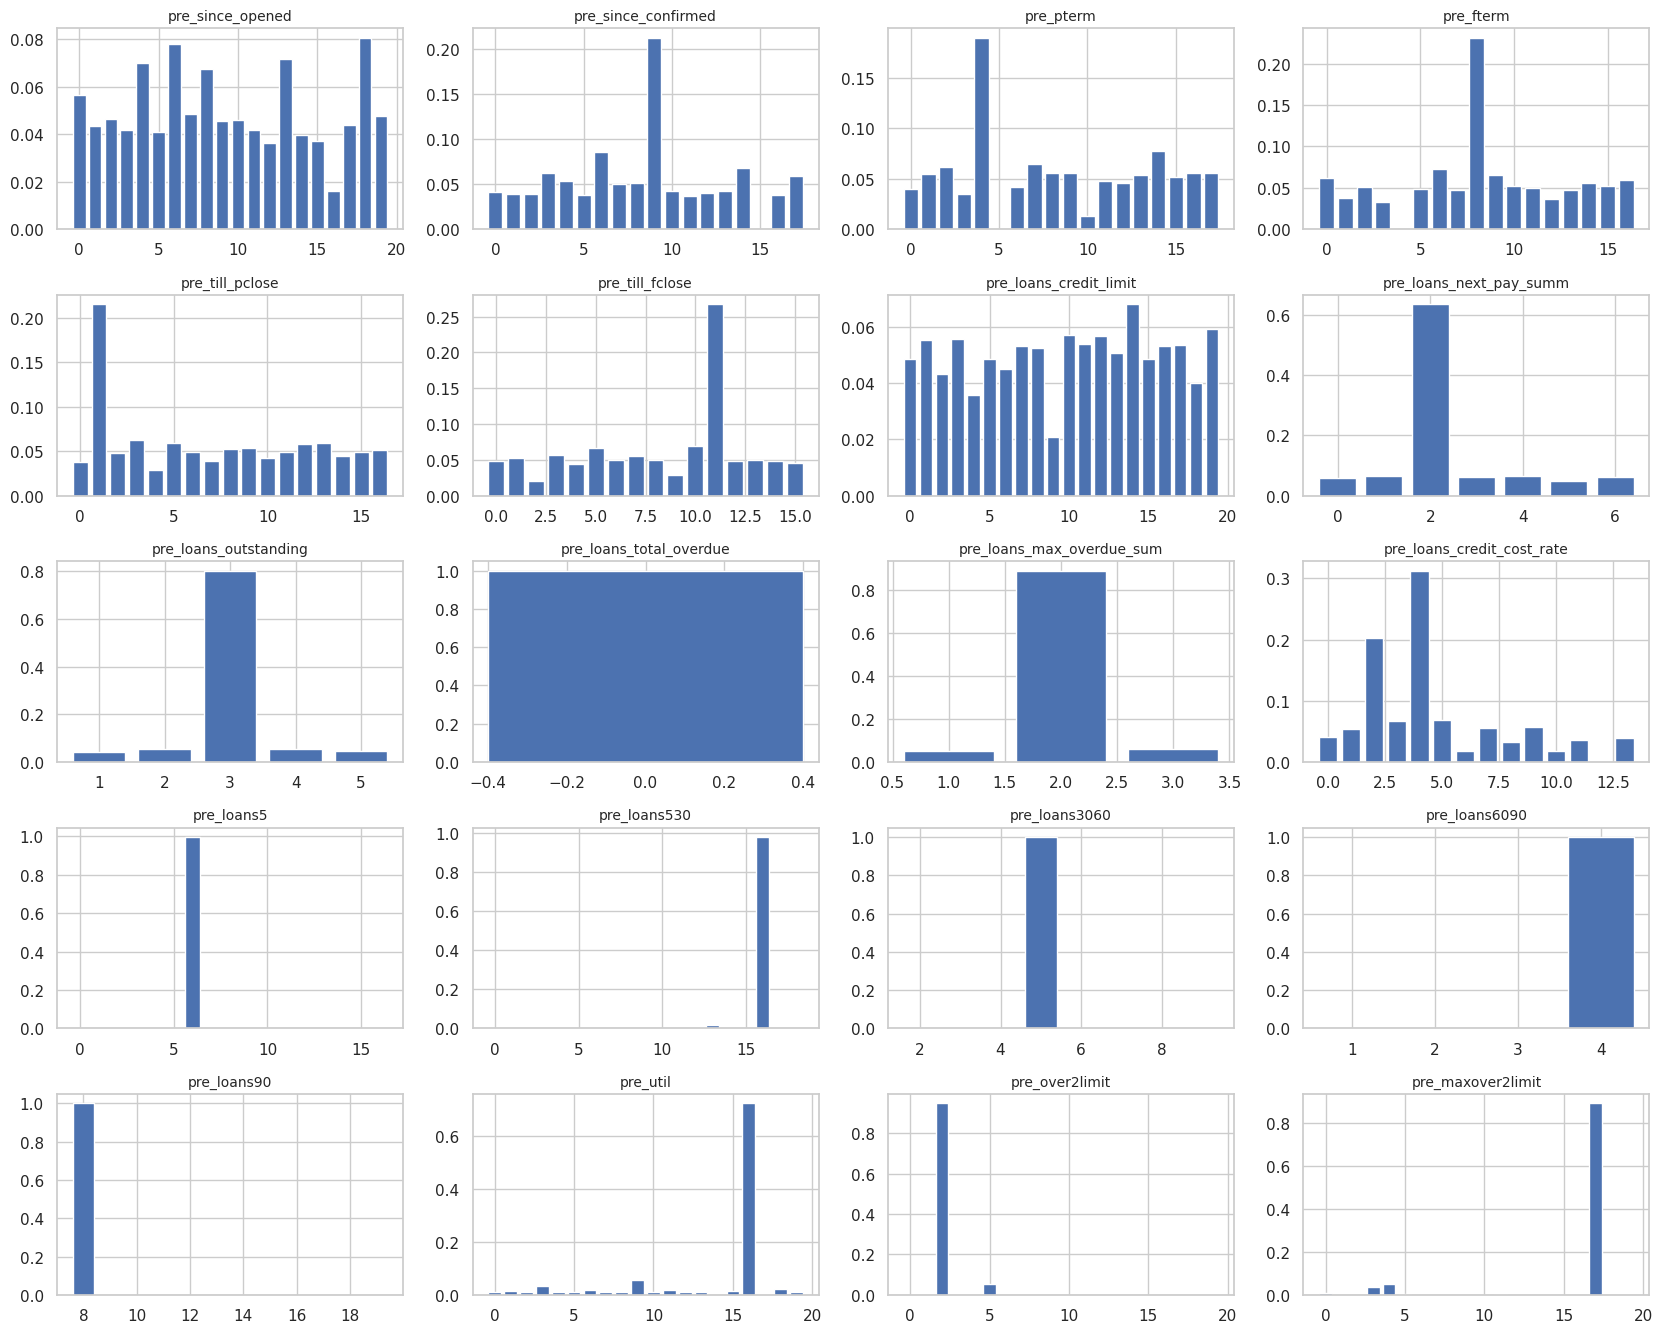

In [ ]:
def plot_value_shares(df, cols, ncols=4, color="#4C72B0"):
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 2.7 * nrows))
    axes = np.array(axes).ravel()
    for ax, c in zip(axes, cols):
        vc = df[c].value_counts(normalize=True).sort_index()
        ax.bar(vc.index.astype(int), vc.values, color=color)
        ax.set_title(c, fontsize=10)
    for ax in axes[len(cols):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()

plot_value_shares(df0, ORD_COLS, ncols=4)

### 6.2 Бинарные флаги
Считаю долю единиц у каждого флага.



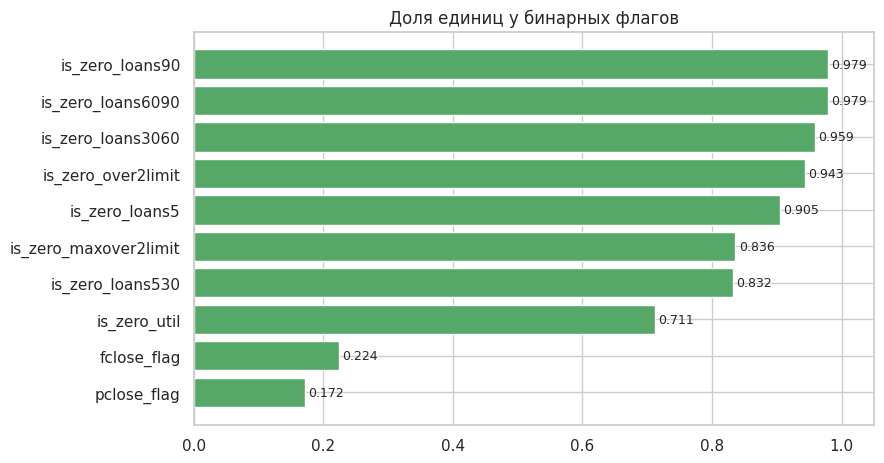

In [ ]:
bin_share = df0[BIN_COLS].mean().sort_values()
fig, ax = plt.subplots(figsize=(9, 0.38 * len(bin_share) + 1))
ax.barh(bin_share.index, bin_share.values, color="#55A868")
for i, v in enumerate(bin_share.values):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, 1.05); ax.set_title("Доля единиц у бинарных флагов")
plt.tight_layout(); plt.show()

### 6.3 Категориальные признаки `enc_loans_*`
Смотрю, как часто встречается каждая категория. Интересно, сколько вообще уровней и есть ли доминирующие или совсем редкие. Дальше эти признаки превращу в доли категорий в истории клиента.

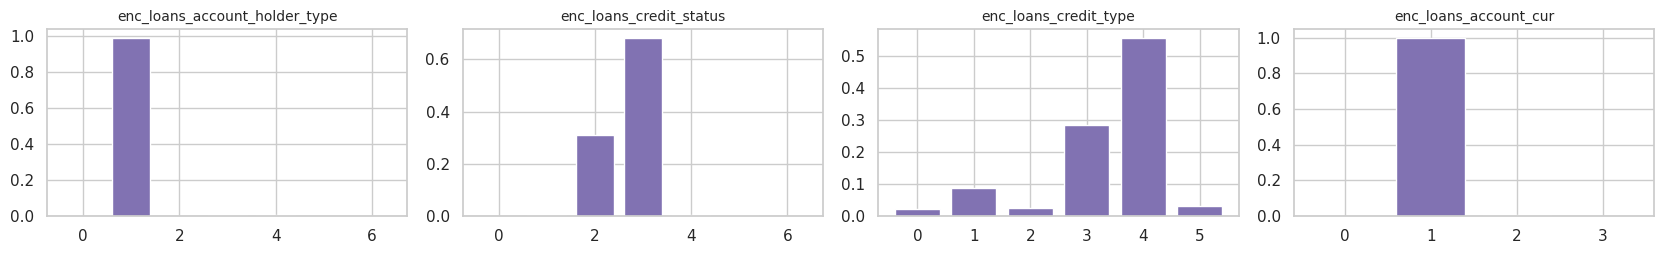

In [ ]:
plot_value_shares(df0, CAT_COLS, ncols=4, color="#8172B2")

### 6.4 История платежей `enc_paym_0 … enc_paym_24`
Смотрю, как меняется распределение по позициям (например, в дальних периодах у молодых кредитов будет больше пустых значений).

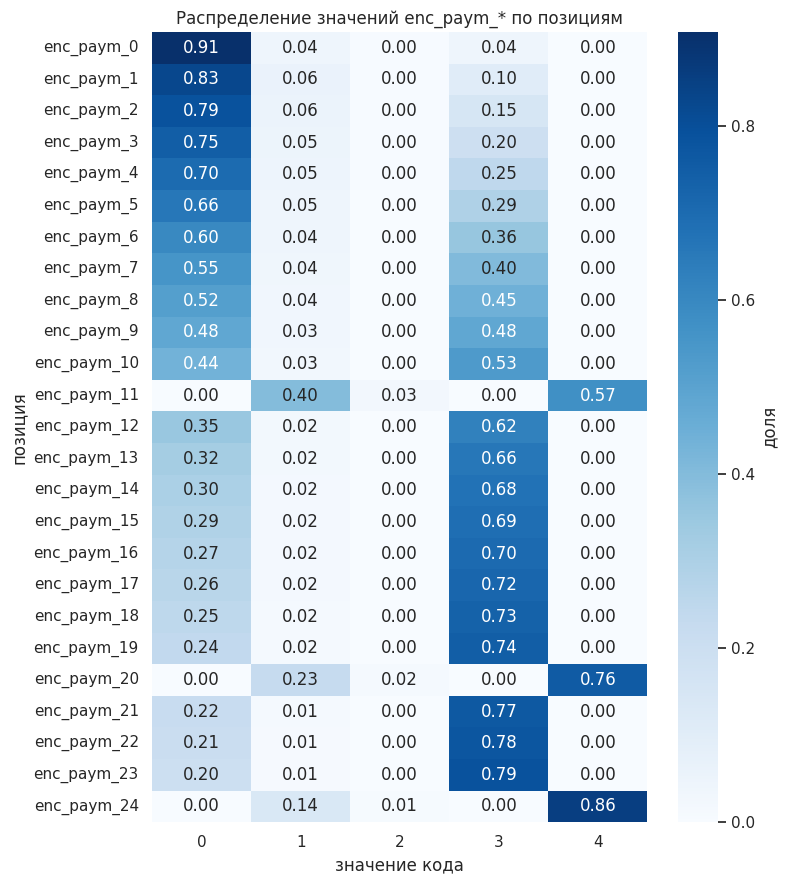

In [ ]:
paym_shares = pd.DataFrame({c: df0[c].value_counts(normalize=True) for c in PAYM_COLS}).T.fillna(0).sort_index(axis=1)
fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(paym_shares, annot=True, fmt=".2f", cmap="Blues", cbar_kws={"label": "доля"}, ax=ax)
ax.set_title("Распределение значений enc_paym_* по позициям"); ax.set_xlabel("значение кода"); ax.set_ylabel("позиция")
plt.tight_layout(); plt.show()

## 7. Связь признаков с таргетом

### 7.1 Доля дефолтов по значениям признака
Для каждого значения признака считаю долю дефолтов и рисую её. Значения, которых слишком мало  выкидываю, так как по ним оценка получается шумной.


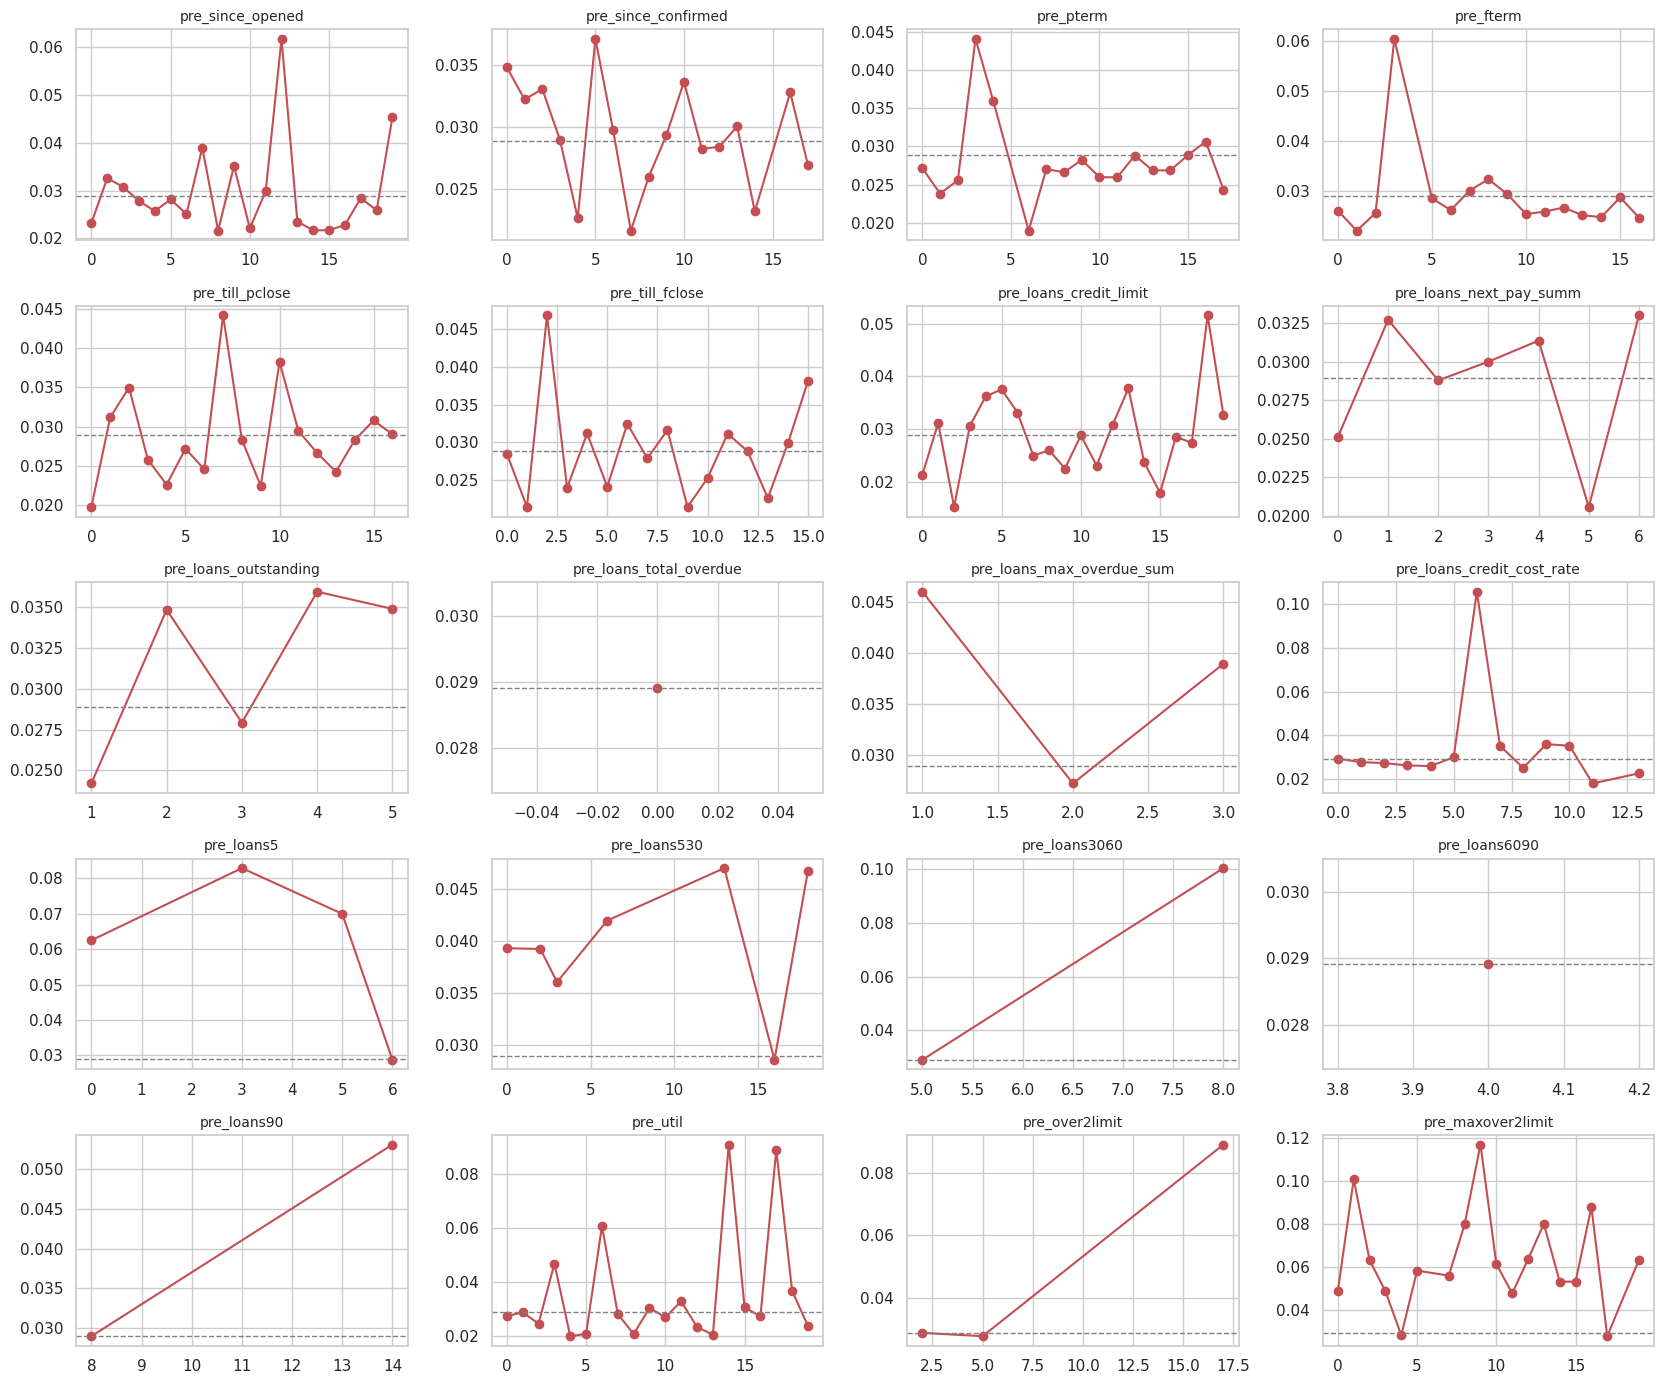

In [ ]:
MIN_SUPPORT = 300   # минимум строк в группе, чтобы верить её доле дефолтов

def rate_table(df, col):
    return df.groupby(col)["flag"].agg(["mean", "count"])

def plot_rate_grid(df, cols, ncols=4, kind="line"):
    base = df["flag"].mean()
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 2.8 * nrows))
    axes = np.array(axes).ravel()
    for ax, c in zip(axes, cols):
        t = rate_table(df, c)
        t = t[t["count"] >= MIN_SUPPORT]
        if kind == "line":
            ax.plot(t.index.astype(int), t["mean"], marker="o", lw=1.5, color="#C44E52")
        else:
            ax.bar(t.index.astype(int), t["mean"], color="#C44E52")
        ax.axhline(base, ls="--", c="gray", lw=1)
        ax.set_title(c, fontsize=10)
    for ax in axes[len(cols):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()

plot_rate_grid(df0, ORD_COLS, ncols=4, kind="line")

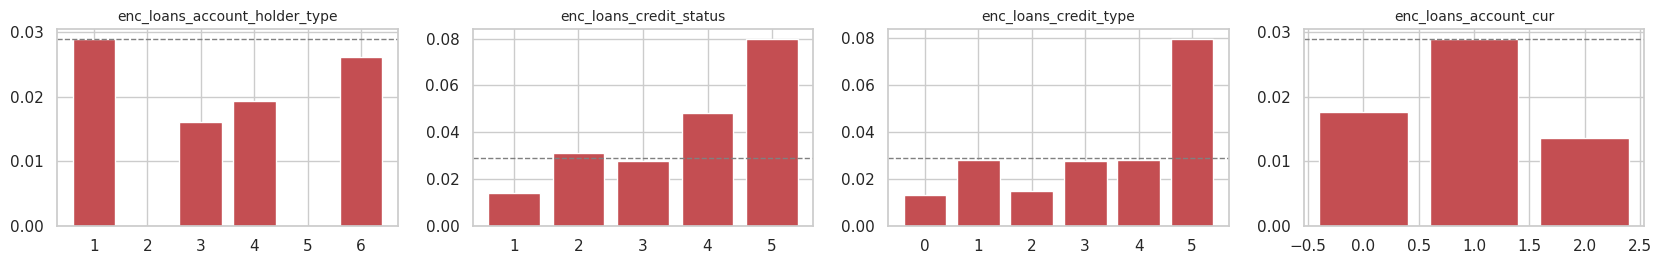

In [ ]:
# то же самое для категориальных, только столбиками
plot_rate_grid(df0, CAT_COLS, ncols=4, kind="bar")

### 7.2 Какие значения платежей нехорошие
Смысл кодов скрыт, но так можно расшифровать их эмпирически если при каком-то значении доля дефолтов резко выше среднего, то, скорее всего, это просрочка. Это подскажет, какие значения стоит считать отдельно при создании признаков.

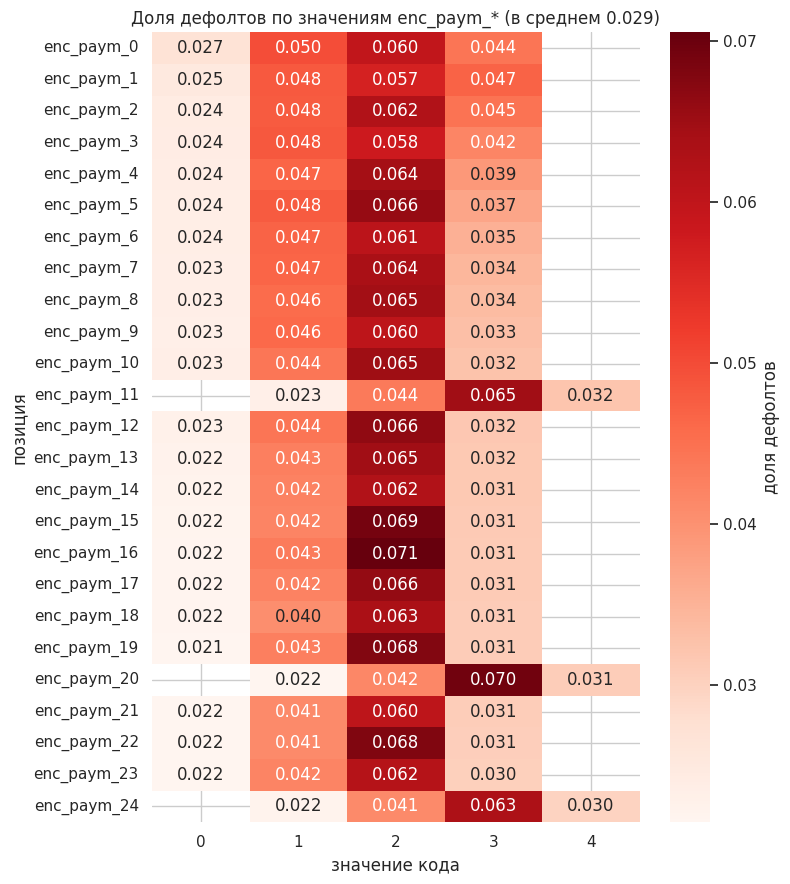

In [ ]:
paym_rate = pd.DataFrame({c: df0.groupby(c)["flag"].mean() for c in PAYM_COLS}).T.sort_index(axis=1)
paym_cnt  = pd.DataFrame({c: df0.groupby(c)["flag"].size() for c in PAYM_COLS}).T.sort_index(axis=1)

fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(paym_rate.where(paym_cnt >= MIN_SUPPORT), annot=True, fmt=".3f", cmap="Reds", ax=ax,
            cbar_kws={"label": "доля дефолтов"})
ax.set_title(f"Доля дефолтов по значениям enc_paym_* (в среднем {df0['flag'].mean():.3f})")
ax.set_xlabel("значение кода"); ax.set_ylabel("позиция")
plt.tight_layout(); plt.show()

### 7.3 Какой признак в одиночку разделяет лучше всех
Для каждого признака считаю ROC AUC, подставляя сам признак вместо скора. Делаю два варианта:

* `auc_raw` — признак «как есть». Подходит для порядковых признаков, у которых эффект монотонный;
* `auc_rate_enc` — сначала заменяю каждое значение на долю дефолтов при этом значении (rate-кодирование), потом считаю AUC. Так ловятся и немонотонные зависимости, и категории.

Дальше $gini = 2\cdot AUC − 1$. Если `auc_raw` сильно отличается от `auc_rate_enc`, связь с таргетом немонотонная.

In [ ]:
sample = df0.sample(min(len(df0), 500_000), random_state=SEED)
rows = []
for c in feature_cols:
    auc_raw = roc_auc_score(sample["flag"], sample[c])
    enc = sample[c].map(sample.groupby(c)["flag"].mean())
    auc_enc = roc_auc_score(sample["flag"], enc)
    rows.append((c, auc_raw, auc_enc))
uni = pd.DataFrame(rows, columns=["feature", "auc_raw", "auc_rate_enc"]).set_index("feature")
uni["gini_raw"] = (2 * (uni["auc_raw"] - 0.5)).abs()
uni["gini_rate_enc"] = 2 * (uni["auc_rate_enc"] - 0.5)
display(uni.sort_values("gini_rate_enc", ascending=False).head(20).round(4))
del sample

,auc_raw,auc_rate_enc,gini_raw,gini_rate_enc
feature,,,,
pre_since_opened,0.5103,0.5743,0.0207,0.1485
pre_loans_credit_limit,0.5126,0.5711,0.0251,0.1422
enc_paym_3,0.5634,0.5667,0.1269,0.1334
enc_paym_4,0.5596,0.5637,0.1191,0.1275
enc_paym_2,0.5618,0.5634,0.1237,0.1268
enc_paym_5,0.5563,0.5622,0.1126,0.1244
enc_paym_7,0.5516,0.5594,0.1031,0.1189
enc_paym_6,0.5504,0.5564,0.1009,0.1127
pre_loans_credit_cost_rate,0.5167,0.5557,0.0333,0.1114


## 8. Корреляции между признаками

Считаю корреляцию Пирсона на случайной выборке строк и рисую две тепловые карты: для параметров кредита и отдельно для истории платежей. Ещё вывожу самые коррелированные пары.

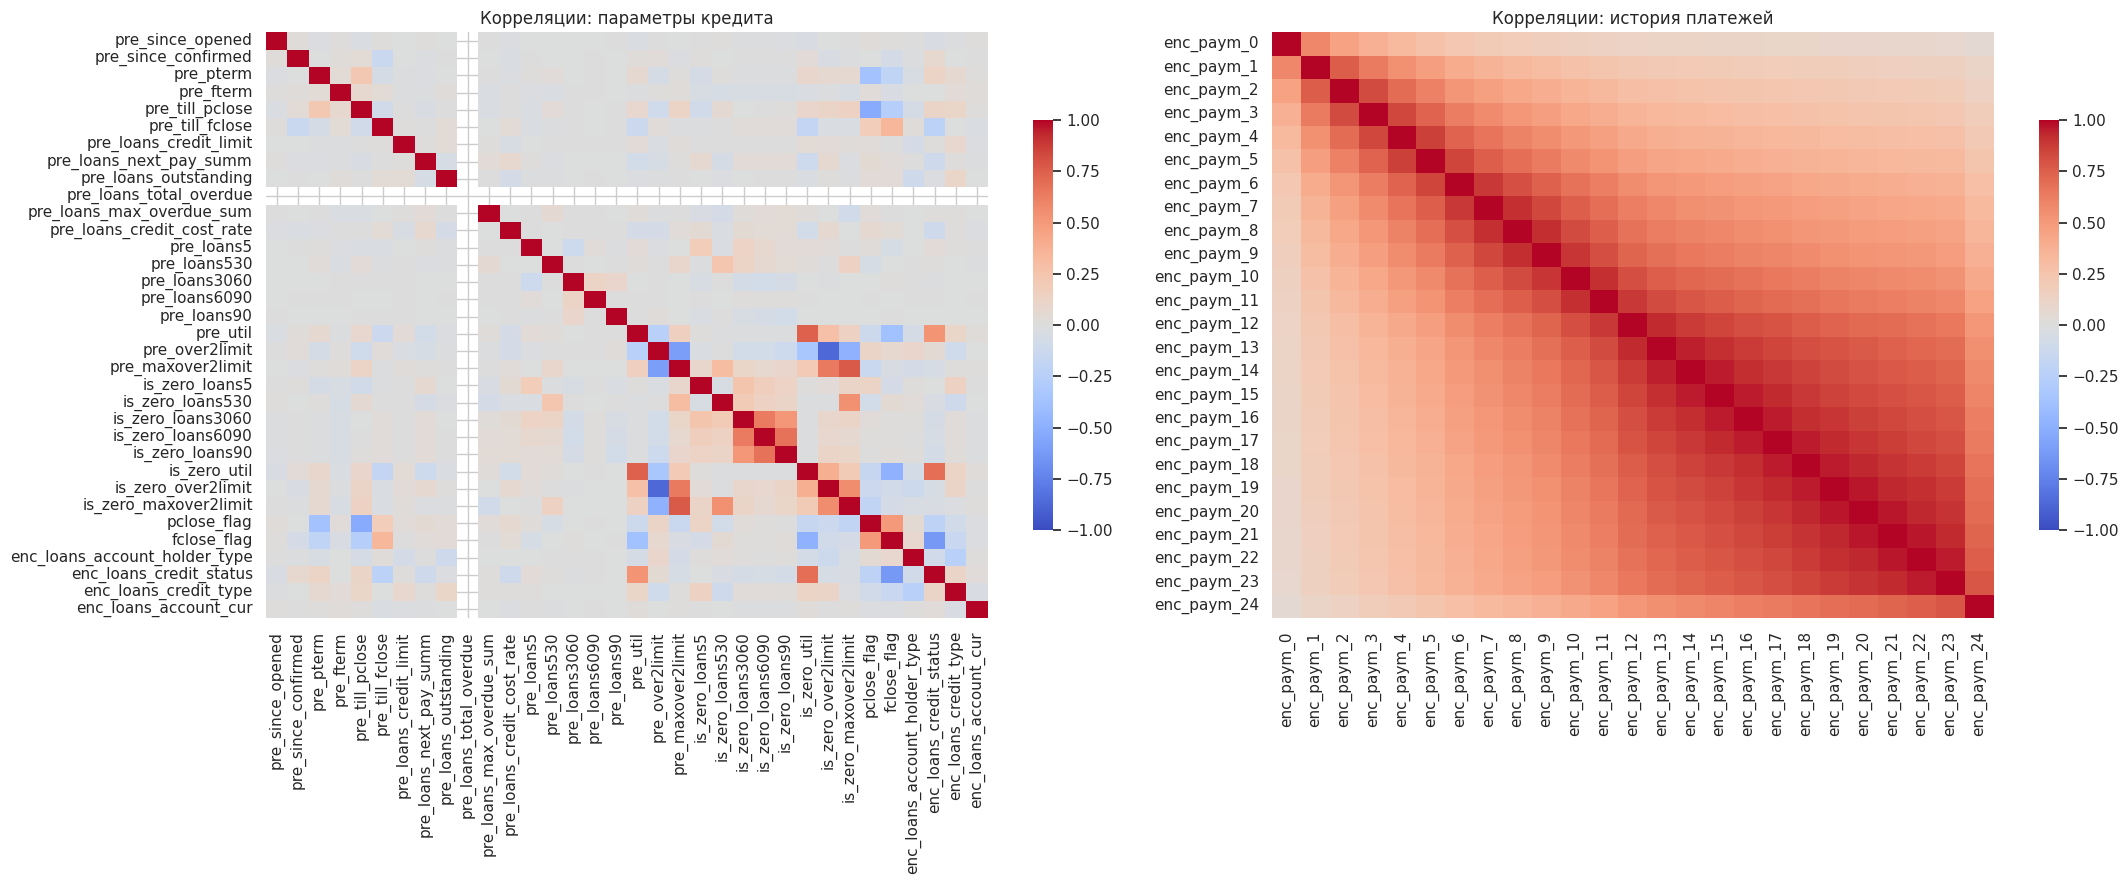

Топ-15 самых коррелированных пар:


,feature_1,feature_2,corr,abs_corr
1701,enc_paym_20,enc_paym_21,0.966,0.966
1705,enc_paym_21,enc_paym_22,0.964,0.964
1696,enc_paym_19,enc_paym_20,0.963,0.963
1690,enc_paym_18,enc_paym_19,0.961,0.961
1675,enc_paym_16,enc_paym_17,0.959,0.959
1708,enc_paym_22,enc_paym_23,0.959,0.959
1666,enc_paym_15,enc_paym_16,0.958,0.958
1656,enc_paym_14,enc_paym_15,0.956,0.956
1683,enc_paym_17,enc_paym_18,0.955,0.955
1645,enc_paym_13,enc_paym_14,0.949,0.949


In [ ]:
corr_sample = df0[feature_cols].sample(min(len(df0), 200_000), random_state=SEED)
corr = corr_sample.corr()

non_paym = [c for c in feature_cols if c not in PAYM_COLS]
fig, ax = plt.subplots(1, 2, figsize=(22, 9))
sns.heatmap(corr.loc[non_paym, non_paym], cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax[0],
            xticklabels=True, yticklabels=True, cbar_kws={"shrink": .7})
ax[0].set_title("Корреляции: параметры кредита")
sns.heatmap(corr.loc[PAYM_COLS, PAYM_COLS], cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax[1],
            xticklabels=True, yticklabels=True, cbar_kws={"shrink": .7})
ax[1].set_title("Корреляции: история платежей")
plt.tight_layout(); plt.show()

iu = np.triu_indices_from(corr.values, k=1)
pairs = pd.DataFrame({"feature_1": corr.index[iu[0]], "feature_2": corr.columns[iu[1]], "corr": corr.values[iu]})
pairs["abs_corr"] = pairs["corr"].abs()
print("Топ-15 самых коррелированных пар:")
display(pairs.sort_values("abs_corr", ascending=False).head(15).round(3))
del corr_sample

## 9. Сравнение train и test

Сравниваю распределения по метрике **PSI** (Population Stability Index):

$$PSI = \sum_i (p_i^{train} - p_i^{test}) \cdot \ln\frac{p_i^{train}}{p_i^{test}}$$

Тут $p_i$ — доля значения $i$ в выборке. Ориентиры: PSI < 0.1 - всё в порядке, 0.1–0.25 - сдвиг заметный, > 0.25 - сильный.

Заодно смотрю, не пересекаются ли `id` в train и test, и похожи ли длины историй.

In [ ]:
test0 = load_part(test_files[0])
test_loans = count_loans(test_files)

print(f"id в train: {loans_per_client.index.min()} … {loans_per_client.index.max()}")
print(f"id в test : {test_loans.index.min()} … {test_loans.index.max()}  (общих id: {len(loans_per_client.index.intersection(test_loans.index))})")
display(pd.DataFrame({"train n_loans": loans_per_client.describe(), "test n_loans": test_loans.describe()}).round(2).T)

def psi_discrete(a, b, eps=1e-6):
    pa, pb = a.value_counts(normalize=True), b.value_counts(normalize=True)
    idx = pa.index.union(pb.index)
    pa, pb = pa.reindex(idx, fill_value=0) + eps, pb.reindex(idx, fill_value=0) + eps
    return float(((pa - pb) * np.log(pa / pb)).sum())

a_s = df0[feature_cols].sample(min(len(df0), 300_000), random_state=SEED)
b_s = test0[feature_cols].sample(min(len(test0), 300_000), random_state=SEED)
psi = pd.Series({c: psi_discrete(a_s[c], b_s[c]) for c in feature_cols}).sort_values(ascending=False)
print("Топ-10 признаков по PSI (train vs test):")
display(psi.head(10).round(5).to_frame("PSI"))
print("Максимальный PSI:", round(psi.max(), 5), "→", "сильных сдвигов нет" if psi.max() < 0.1 else "есть заметные сдвиги, стоит присмотреться")
del a_s, b_s

id в train: 0 … 1499999
id в test : 3000000 … 3499999  (общих id: 0)


,count,mean,std,min,25%,50%,75%,max
train n_loans,1500000.0,8.33,5.99,1.0,4.0,7.0,12.0,51.0
test n_loans,500000.0,9.45,6.58,1.0,4.0,8.0,14.0,57.0


Топ-10 признаков по PSI (train vs test):


,PSI
enc_loans_credit_type,0.52561
pre_since_opened,0.19920
pre_since_confirmed,0.07567
pre_loans_credit_cost_rate,0.07115
pre_till_fclose,0.04948
pre_till_pclose,0.04700
pre_loans_credit_limit,0.03332
pre_maxover2limit,0.03280
pre_loans_next_pay_summ,0.02654
pre_loans_max_overdue_sum,0.02507


Максимальный PSI: 0.52561 → есть заметные сдвиги, стоит присмотреться


## 10. Сжатие историю до одной строки на клиента

У клиента от 1 до N строк, а модели нужна ровно одна строка на клиента. Поэтому агрегируем строки по каждому клиенту

| Блок признаков | Что считаем |
|---|---|
| Размер истории | `n_loans`, `rn__max` |
| Порядковые `pre_*` | среднее, максимум, минимум, std |
| Бинарные флаги | доля единиц и сумма | какая доля кредитов с просрочкой или без неё |
| Платежи по позициям | среднее `enc_paym_i` |
| Платежи по значениям кода | сколько раз встретился каждый код в строке кредита: среднее, максимум, сумма по клиенту |
| Просрочки | `delay_any` (была ли хоть какая-то просрочка) и `delay_types` (сколько видов просрочек) по флагам `is_zero_loans*` |
| Категории `enc_loans_*` | доля каждой категории в истории |
| Первый и последний кредит | `first` и `last` по `rn` |


In [ ]:
def build_client_features(df):
    # сортируем по клиенту и номеру кредита
    df = df.sort_values([ID_COL, RN_COL], kind="stable")
    g = df.groupby(ID_COL, sort=False)
    blocks = []

    # 1) размер истории
    blocks.append(g.size().rename("n_loans").to_frame())
    blocks.append(g[RN_COL].max().rename("rn__max").to_frame())

    # 2) порядковые pre_*: среднее / макс / мин / std
    a = g[ORD_COLS].agg(["mean", "max", "min", "std"])
    a.columns = [f"{c}__{s}" for c, s in a.columns]
    blocks.append(a)

    # 3) бинарные флаги: доля и сумма
    b = g[BIN_COLS].agg(["mean", "sum"])
    b.columns = [f"{c}__{s}" for c, s in b.columns]
    blocks.append(b)

    # 4) платежи: среднее по каждой позиции enc_paym_i
    p = g[PAYM_COLS].mean()
    p.columns = [f"{c}__mean" for c in p.columns]
    blocks.append(p)

    # 5) признаки на уровне одного кредита, которые потом агрегируем по клиенту
    arr = df[PAYM_COLS].to_numpy()
    row = {f"paym_cnt_v{v}": (arr == v).sum(axis=1) for v in PAYM_LEVELS}   # сколько раз в кредите встретился код v
    row["paym_row_max"] = arr.max(axis=1)
    row["paym_row_mean"] = arr.mean(axis=1)
    if ZERO_LOAN_COLS:
        has_delay = (df[ZERO_LOAN_COLS].to_numpy() == 0)      # флаг "нет просрочки" == 0, значит просрочка была
        row["delay_any"] = has_delay.any(axis=1).astype("int8")
        row["delay_types"] = has_delay.sum(axis=1)
    row = pd.DataFrame(row, index=df.index)
    row[ID_COL] = df[ID_COL].to_numpy()
    r = row.groupby(ID_COL, sort=False).agg(["mean", "max", "sum"])
    r.columns = [f"{c}__{s}" for c, s in r.columns]
    blocks.append(r)

    # 6) категории: доли каждой категории в истории клиента
    n_loans = g.size()
    for c in CAT_COLS:
        cnt = (df.groupby([ID_COL, c], sort=False).size().unstack(fill_value=0)
                 .reindex(columns=CAT_LEVELS[c], fill_value=0))
        share = cnt.div(n_loans.reindex(cnt.index), axis=0)
        share.columns = [f"{c}__share_{lvl}" for lvl in share.columns]
        blocks.append(share)

    # 7) первый и последний кредит клиента (по rn)
    sel = ORD_COLS + CAT_COLS
    f_ = g[sel].first(); f_.columns = [f"{c}__first" for c in f_.columns]
    l_ = g[sel].last();  l_.columns = [f"{c}__last" for c in l_.columns]
    blocks += [f_, l_]

    X = pd.concat(blocks, axis=1).sort_index()
    return X.astype("float32")


def build_features(files, name):
    cache = CACHE_DIR / f"{name}_{len(files)}files.pq"
    if USE_CACHE and cache.exists():
        print(f"[{name}] беру готовое из кэша: {cache}")
        return pd.read_parquet(cache)
    parts = []
    for i, path in enumerate(files, 1):
        t0 = time.time()
        part = load_part(path)
        parts.append(build_client_features(part))
        print(f"[{name}] файл {i}/{len(files)}: {len(part):,} строк → {len(parts[-1]):,} клиентов, {time.time() - t0:.0f} c")
        del part; gc.collect()
    X = pd.concat(parts)
    assert X.index.is_unique, "Один и тот же id встретился в разных файлах — агрегаты надо считать по объединённым строкам"
    X = X.sort_index()
    if USE_CACHE:
        X.to_parquet(cache)
    return X

X_train = build_features(train_files, "train")
X_test  = build_features(test_files, "test")
y = target.reindex(X_train.index)

assert y.notna().all(), "У части клиентов из train нет таргета"
assert list(X_train.columns) == list(X_test.columns), "Признаки в train и test не совпадают"
assert X_train.columns.is_unique
y = y.astype("int8")

print(f"\nX_train: {X_train.shape}  ({X_train.memory_usage().sum() / 1024**2:.0f} MB)")
print(f"X_test : {X_test.shape}")
print(f"Доля дефолтов в train: {y.mean():.4f}")

[train] файл 1/6: 1,974,724 строк → 250,000 клиентов, 6 c
[train] файл 2/6: 2,107,305 строк → 250,000 клиентов, 6 c
[train] файл 3/6: 2,080,508 строк → 250,000 клиентов, 7 c
[train] файл 4/6: 2,112,592 строк → 250,000 клиентов, 6 c
[train] файл 5/6: 2,064,110 строк → 250,000 клиентов, 6 c
[train] файл 6/6: 2,150,908 строк → 250,000 клиентов, 6 c
[test] файл 1/2: 2,389,773 строк → 250,000 клиентов, 7 c
[test] файл 2/2: 2,334,828 строк → 250,000 клиентов, 10 c

X_train: (1500000, 226)  (1323 MB)
X_test : (500000, 226)
Доля дефолтов в train: 0.0355


### 10.1 Проверяем, что агрегаты получились нормальные
1. Смотрю пропуски. Ожидаю, что они будут только в `*__std` (у клиентов с одним кредитом).
2. Считаю одномерную силу агрегатов, но теперь на уровне клиентов.

Если у лучших признаков Gini заметно выше нуля, значит агрегация сработала и сигнал не потерялся. (NaN заполняю −1 только для этой проверки.)

In [ ]:
na_share = X_train.isna().mean().sort_values(ascending=False)
print("Колонки с пропусками (топ-5):")
display(na_share.head(5).round(4).to_frame("доля NaN"))

idx = np.random.RandomState(SEED).choice(len(X_train), size=min(300_000, len(X_train)), replace=False)
Xs, ys = X_train.iloc[idx], y.iloc[idx]
uni_client = pd.Series({c: roc_auc_score(ys, Xs[c].fillna(-1)) for c in X_train.columns})
uni_client = pd.DataFrame({"auc": uni_client, "gini_abs": (2 * (uni_client - 0.5)).abs()}).sort_values("gini_abs", ascending=False)
print("Топ-20 агрегатов по одномерному Gini (уровень клиентов):")
display(uni_client.head(20).round(4))
del Xs, ys

Колонки с пропусками (топ-5):


,доля NaN
pre_since_confirmed__std,0.0788
pre_since_opened__std,0.0788
pre_loans_credit_limit__std,0.0788
pre_loans_next_pay_summ__std,0.0788
pre_fterm__std,0.0788


Топ-20 агрегатов по одномерному Gini (уровень клиентов):


,auc,gini_abs
paym_cnt_v0__mean,0.3411,0.3179
paym_row_mean__mean,0.6370,0.2741
paym_cnt_v3__mean,0.6261,0.2521
paym_cnt_v0__max,0.3776,0.2448
enc_paym_3__mean,0.6187,0.2375
enc_paym_4__mean,0.6186,0.2371
enc_paym_2__mean,0.6171,0.2342
enc_paym_5__mean,0.6155,0.2311
enc_paym_1__mean,0.6140,0.2281
enc_paym_6__mean,0.6116,0.2233


### 10.2 Отличим ли train от test?
Склеиваю выборки из train и test, ставлю метки «train = 0, test = 1» и пробую обучить LightGBM отличать одно от другого (3-fold).

In [ ]:
n_adv = min(50_000, len(X_test))
adv_X = pd.concat([X_train.sample(n_adv, random_state=SEED), X_test.sample(n_adv, random_state=SEED)])
adv_y = np.r_[np.zeros(n_adv), np.ones(n_adv)]

adv_model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31, subsample=0.8, subsample_freq=1,
                               colsample_bytree=0.5, random_state=SEED, verbose=-1)
adv_pred = cross_val_predict(adv_model, adv_X, adv_y, cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
                             method="predict_proba")[:, 1]
print(f"Adversarial AUC (train vs test): {roc_auc_score(adv_y, adv_pred):.4f}   (около 0.5 = выборки неотличимы)")
adv_model.fit(adv_X, adv_y)
display(pd.Series(adv_model.feature_importances_, index=adv_X.columns).nlargest(8).to_frame("importance (число сплитов)"))
del adv_X, adv_y, adv_model, adv_pred

Adversarial AUC (train vs test): 0.9252   (около 0.5 = выборки неотличимы)


,importance (число сплитов)
pre_since_confirmed__first,430
pre_loans_credit_cost_rate__first,213
pclose_flag__mean,203
pre_pterm__last,195
pre_loans_credit_cost_rate__last,171
enc_loans_credit_type__first,156
enc_loans_credit_type__last,152
pre_loans_credit_cost_rate__min,139


## 11. Модели

### 11.1 Валидация
Использую `StratifiedKFold`: данные делятся на K частей с одинаковой долей дефолтов, каждая часть по очереди становится валидационной, остальные идут в обучение. Фолды фиксирую один раз и использую для всех моделей
### 11.2 Метрики
* ROC AUC;
* $Gini = 2 \cdot AUC − 1$;
* Колмогоров-Смирнов;
* PR AUC.

In [ ]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(X_train, y))
print("Фолдов:", len(folds), "| размер train/valid в первом фолде:", len(folds[0][0]), "/", len(folds[0][1]))

def ks_stat(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return float(np.max(tpr - fpr))

def report(name, y_true, y_score):
    auc = roc_auc_score(y_true, y_score)
    return {"model": name, "ROC AUC": auc, "Gini": 2 * auc - 1, "KS": ks_stat(y_true, y_score),
            "PR AUC": average_precision_score(y_true, y_score)}

results = []
y_arr = y.to_numpy()

Фолдов: 3 | размер train/valid в первом фолде: 1000000 / 500000


### 11.3 Бейслайн 0: константа
Если всем клиентам выдать одну и ту же вероятность (долю дефолтов), получаю ROC AUC = 0.5. Любая нормальная модель должна быть хотя бы лучше. Дальше эту планку не считаю.

### 11.4 Бейслайн 1: логистическая регрессия
Самая простая модель: `StandardScaler` + `LogisticRegression`, учиу на первом фолде. `NaN` (в `*__std`) заменяю нулями, потому что логрег пропуски не понимает, а «нет разброса» = 0 выглядит разумно.



In [ ]:
tr, va = folds[0]
t0 = time.time()
lr_model = make_pipeline(StandardScaler(), LogisticRegression(C=0.05, max_iter=200))
lr_model.fit(X_train.iloc[tr].fillna(0), y_arr[tr])
lr_valid_pred = lr_model.predict_proba(X_train.iloc[va].fillna(0))[:, 1]

results.append(report("Logistic Regression (fold 0)", y_arr[va], lr_valid_pred))
print(f"Учился {time.time() - t0:.0f} c")
display(pd.DataFrame(results).set_index("model").round(4))

Учился 25 c


,ROC AUC,Gini,KS,PR AUC
model,,,,
Logistic Regression (fold 0),0.7339,0.4677,0.3484,0.0985


### 11.5 Основная модель: LightGBM
Градиентный бустинг строит много небольших деревьев по очереди, и каждое новое старается исправить ошибки предыдущих.

Число деревьев руками не задаю: если AUC на валидации не растёт 100 итераций подряд, обучение останавливается и берётся лучшая итерация.

В каждом фолде сохраняю OOF-предсказания (на отложенной части) для честной оценки, а для test усредняю предсказания всех K моделей.

In [ ]:
lgb_params = dict(objective="binary", metric="auc", learning_rate=LGB_LR, num_leaves=63, min_child_samples=100,
                  feature_fraction=0.5, bagging_fraction=0.8, bagging_freq=1, lambda_l2=10.0,
                  max_bin=255, seed=SEED, verbose=-1)

####Подбор гиперпараметров через Optuna
Подбор идёт на подвыборке до 300 тысяч клиентов и на одном фолде. Найденные параметры потом применяются в полной кросс-валидации.


In [ ]:
if RUN_OPTUNA:
    try:
        import optuna
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        tr_idx, va_idx = folds[0]
        sub_tr = np.random.RandomState(SEED).choice(tr_idx, size=min(len(tr_idx), 300_000), replace=False)

        def objective(trial):
            params = {**lgb_params,
                      "num_leaves": trial.suggest_int("num_leaves", 16, 256, log=True),
                      "min_child_samples": trial.suggest_int("min_child_samples", 20, 500),
                      "feature_fraction": trial.suggest_float("feature_fraction", 0.3, 0.9),
                      "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
                      "lambda_l2": trial.suggest_float("lambda_l2", 1e-2, 100.0, log=True)}
            dtr = lgb.Dataset(X_train.iloc[sub_tr], y_arr[sub_tr])
            dva = lgb.Dataset(X_train.iloc[va_idx], y_arr[va_idx], reference=dtr)
            m = lgb.train(params, dtr, 2000, valid_sets=[dva], callbacks=[lgb.early_stopping(50, verbose=False)])
            return m.best_score["valid_0"]["auc"]

        study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
        study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)
        print("Лучший AUC на валидации:", round(study.best_value, 5))
        print("Лучшие параметры:", study.best_params)
        lgb_params.update(study.best_params)
    except ImportError:
        print("optuna не установлен: pip install optuna")
else:
    print("Подбор гиперпараметров выключен (RUN_OPTUNA = False). Берём параметры по умолчанию:")
    print(lgb_params)

Подбор гиперпараметров выключен (RUN_OPTUNA = False). Берём параметры по умолчанию:
{'objective': 'binary', 'metric': 'auc', 'learning_rate': 0.1, 'num_leaves': 63, 'min_child_samples': 100, 'feature_fraction': 0.5, 'bagging_fraction': 0.8, 'bagging_freq': 1, 'lambda_l2': 10.0, 'max_bin': 255, 'seed': 42, 'verbose': -1}


Теперь сама кросс-валидация. Функция для каждого фолда обучает модель, считает AUC на валидации, сохраняет OOF-предсказания, предсказания для test и важность признаков.

In [ ]:
def run_lgb_cv(X, y_arr, X_test, params, folds, num_boost_round=5000, early_stopping=100):
    oof = np.zeros(len(X))
    test_pred = np.zeros(len(X_test))
    importances = pd.DataFrame(index=X.columns)
    models, fold_auc = [], []
    for k, (tr, va) in enumerate(folds):
        t0 = time.time()
        dtr = lgb.Dataset(X.iloc[tr], y_arr[tr])
        dva = lgb.Dataset(X.iloc[va], y_arr[va], reference=dtr)
        m = lgb.train(params, dtr, num_boost_round, valid_sets=[dva],
                      callbacks=[lgb.early_stopping(early_stopping, verbose=False)])
        oof[va] = m.predict(X.iloc[va], num_iteration=m.best_iteration)
        test_pred += m.predict(X_test, num_iteration=m.best_iteration) / len(folds)
        importances[f"fold{k}"] = m.feature_importance("gain")
        fold_auc.append(roc_auc_score(y_arr[va], oof[va])); models.append(m)
        print(f"fold {k}: AUC = {fold_auc[-1]:.5f} | деревьев: {m.best_iteration} | {time.time() - t0:.0f} c")
    print(f"\nOOF AUC = {roc_auc_score(y_arr, oof):.5f} | среднее по фолдам = {np.mean(fold_auc):.5f} ± {np.std(fold_auc):.5f}")
    return dict(oof=oof, test=test_pred, imp=importances, models=models, fold_auc=fold_auc)

lgb_res = run_lgb_cv(X_train, y_arr, X_test, lgb_params, folds)
oof_lgb, test_lgb = lgb_res["oof"], lgb_res["test"]

results.append(report("LightGBM (OOF)", y_arr, oof_lgb))
# для честного сравнения с логрегом смотрим тот же самый фолд 0
results.append(report("LightGBM (fold 0)", y_arr[folds[0][1]], oof_lgb[folds[0][1]]))
display(pd.DataFrame(results).set_index("model").round(4))

fold 0: AUC = 0.76447 | деревьев: 251 | 248 c
fold 1: AUC = 0.76488 | деревьев: 189 | 216 c
fold 2: AUC = 0.76446 | деревьев: 242 | 243 c

OOF AUC = 0.76459 | среднее по фолдам = 0.76461 ± 0.00020


,ROC AUC,Gini,KS,PR AUC
model,,,,
Logistic Regression (fold 0),0.7339,0.4677,0.3484,0.0985
LightGBM (OOF),0.7646,0.5292,0.3930,0.1199
LightGBM (fold 0),0.7645,0.5289,0.3951,0.1206


Разброс AUC между фолдами показывает, насколько оценка устойчива. Если улучшение от очередного эксперимента меньше этого разброса, то скорее всего это просто шум.


### 11.6 Вторая модель: CatBoost
У CatBoost другой симметричные деревья и другой способ борьбы с переобучением, поэтому ошибается он не так же, как LightGBM. А когда две модели ошибаются по-разному, их смесь (блендинг) обычно получается лучше каждой из них по отдельности.



In [ ]:
try:
    from catboost import CatBoostClassifier
    HAS_CB = RUN_CATBOOST
except ImportError:
    HAS_CB = False
    print("catboost не установлен, пропускаем (pip install catboost)")

def run_cb_cv(X, y_arr, X_test, folds):
    oof = np.zeros(len(X)); test_pred = np.zeros(len(X_test)); fold_auc = []
    for k, (tr, va) in enumerate(folds):
        t0 = time.time()
        m = CatBoostClassifier(iterations=CB_ITERS, learning_rate=0.1 if FAST_MODE else 0.05, depth=6, l2_leaf_reg=5,
                               loss_function="Logloss", eval_metric="AUC", random_seed=SEED,
                               early_stopping_rounds=100, verbose=0, thread_count=-1)
        m.fit(X.iloc[tr], y_arr[tr], eval_set=(X.iloc[va], y_arr[va]), use_best_model=True)
        oof[va] = m.predict_proba(X.iloc[va])[:, 1]
        test_pred += m.predict_proba(X_test)[:, 1] / len(folds)
        fold_auc.append(roc_auc_score(y_arr[va], oof[va]))
        print(f"fold {k}: AUC = {fold_auc[-1]:.5f} | деревьев: {m.get_best_iteration()} | {time.time() - t0:.0f} c")
    print(f"\nOOF AUC = {roc_auc_score(y_arr, oof):.5f} | среднее по фолдам = {np.mean(fold_auc):.5f} ± {np.std(fold_auc):.5f}")
    return dict(oof=oof, test=test_pred, fold_auc=fold_auc)

if HAS_CB:
    cb_res = run_cb_cv(X_train, y_arr, X_test, folds)
    oof_cb, test_cb = cb_res["oof"], cb_res["test"]
    results.append(report("CatBoost (OOF)", y_arr, oof_cb))
display(pd.DataFrame(results).set_index("model").round(4))

fold 0: AUC = 0.76072 | деревьев: 399 | 272 c
fold 1: AUC = 0.76128 | деревьев: 399 | 268 c
fold 2: AUC = 0.76069 | деревьев: 399 | 271 c

OOF AUC = 0.76088 | среднее по фолдам = 0.76090 ± 0.00027


,ROC AUC,Gini,KS,PR AUC
model,,,,
Logistic Regression (fold 0),0.7339,0.4677,0.3484,0.0985
LightGBM (OOF),0.7646,0.5292,0.3930,0.1199
LightGBM (fold 0),0.7645,0.5289,0.3951,0.1206
CatBoost (OOF),0.7609,0.5218,0.3882,0.1182


### 11.7 Блендинг
Смешиваю предсказания двух моделей. Раз метрика AUC, смешиваю не вероятности, а ранги: каждый скор заменяю на его процентиль. Тогда не важно, что у моделей разный масштаб и калибровка. Вес $w$ подбираю перебором по сетке по OOF.



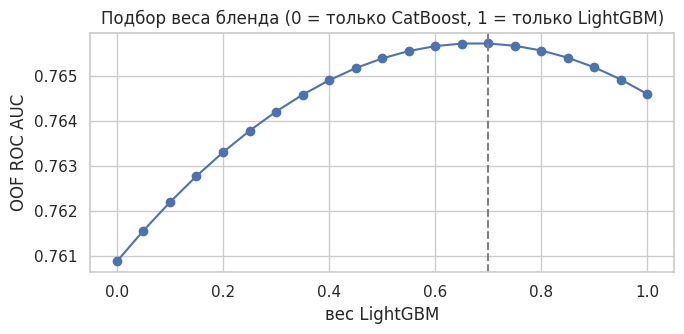

,ROC AUC,Gini,KS,PR AUC
model,,,,
Logistic Regression (fold 0),0.7339,0.4677,0.3484,0.0985
LightGBM (OOF),0.7646,0.5292,0.3930,0.1199
LightGBM (fold 0),0.7645,0.5289,0.3951,0.1206
CatBoost (OOF),0.7609,0.5218,0.3882,0.1182
Blend (w_lgb=0.70),0.7657,0.5314,0.3957,0.1214


In [ ]:
def rank01(x):
    return rankdata(x) / len(x)

if HAS_CB:
    weights = np.linspace(0, 1, 21)
    blend_auc = [roc_auc_score(y_arr, w * rank01(oof_lgb) + (1 - w) * rank01(oof_cb)) for w in weights]
    best_w = float(weights[int(np.argmax(blend_auc))])
    final_oof  = best_w * rank01(oof_lgb)  + (1 - best_w) * rank01(oof_cb)
    final_test = best_w * rank01(test_lgb) + (1 - best_w) * rank01(test_cb)
    results.append(report(f"Blend (w_lgb={best_w:.2f})", y_arr, final_oof))

    plt.figure(figsize=(7, 3.5))
    plt.plot(weights, blend_auc, marker="o"); plt.axvline(best_w, ls="--", c="gray")
    plt.xlabel("вес LightGBM"); plt.ylabel("OOF ROC AUC"); plt.title("Подбор веса бленда (0 = только CatBoost, 1 = только LightGBM)")
    plt.tight_layout(); plt.show()
else:
    final_oof, final_test = oof_lgb, test_lgb
    print("CatBoost не использовался → финальная модель это LightGBM")

final_name = results[-1]["model"]
display(pd.DataFrame(results).set_index("model").round(4))

## 12. Качество модели

### 12.1 Графики
По OOF-предсказаниям финальной модели строю:

1. ROC-кривая — чем сильнее она выгибается над диагональю, тем лучше;
2. Precision–Recall — важна при редком классе, показывает, какой ценой по точности мы добираем полноту;
3. Распределение скоров по классам — чем меньше пересечение «плохих» и «хороших», тем лучше разделение;
4. Калибровка LightGBM — совпадает ли предсказанная вероятность с реальной долей дефолтов (точки должны лежать на диагонали). Для PD это важно, а AUC калибровку вообще не проверяет.

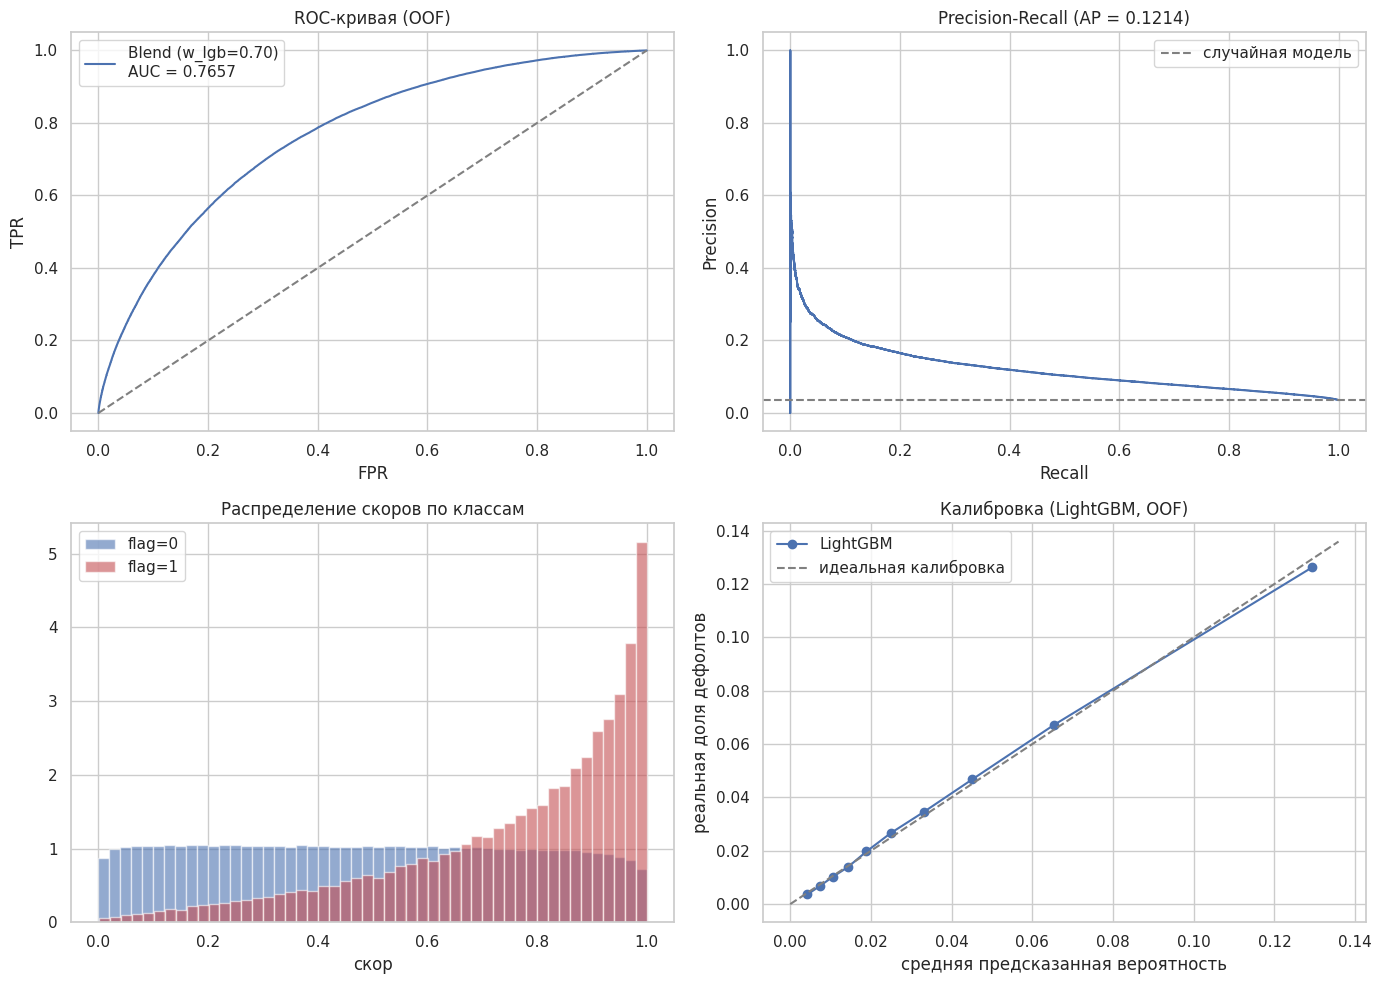

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

fpr, tpr, _ = roc_curve(y_arr, final_oof)
ax[0, 0].plot(fpr, tpr, label=f"{final_name}\nAUC = {roc_auc_score(y_arr, final_oof):.4f}")
ax[0, 0].plot([0, 1], [0, 1], "--", c="gray")
ax[0, 0].set_title("ROC-кривая (OOF)"); ax[0, 0].set_xlabel("FPR"); ax[0, 0].set_ylabel("TPR"); ax[0, 0].legend()

prec, rec, _ = precision_recall_curve(y_arr, final_oof)
ax[0, 1].plot(rec, prec); ax[0, 1].axhline(y_arr.mean(), ls="--", c="gray", label="случайная модель")
ax[0, 1].set_title(f"Precision-Recall (AP = {average_precision_score(y_arr, final_oof):.4f})")
ax[0, 1].set_xlabel("Recall"); ax[0, 1].set_ylabel("Precision"); ax[0, 1].legend()

for cls, color in [(0, "#4C72B0"), (1, "#C44E52")]:
    ax[1, 0].hist(final_oof[y_arr == cls], bins=50, alpha=0.6, density=True, color=color, label=f"flag={cls}")
ax[1, 0].set_title("Распределение скоров по классам"); ax[1, 0].set_xlabel("скор"); ax[1, 0].legend()

frac_pos, mean_pred = calibration_curve(y_arr, oof_lgb, n_bins=10, strategy="quantile")
ax[1, 1].plot(mean_pred, frac_pos, marker="o", label="LightGBM")
lim = max(mean_pred.max(), frac_pos.max()) * 1.05
ax[1, 1].plot([0, lim], [0, lim], "--", c="gray", label="идеальная калибровка")
ax[1, 1].set_title("Калибровка (LightGBM, OOF)"); ax[1, 1].set_xlabel("средняя предсказанная вероятность")
ax[1, 1].set_ylabel("реальная доля дефолтов"); ax[1, 1].legend()
plt.tight_layout(); plt.show()

### 12.2 Децильная таблица (lift)
Сортирую клиентов по скору и делю на 10 равных групп (децилей). Группа 1 — самые рискованные. Для каждой считаю долю дефолтов.

 Колонка $lift$ показывает, во сколько раз доля дефолтов в группе выше средней, а $part$ — какую долю всех дефолтов мы уже «поймали» первыми группами.

In [ ]:
dec = pd.DataFrame({"y": y_arr, "score": final_oof})
dec["decile"] = pd.qcut(dec["score"].rank(method="first"), 10, labels=list(range(10, 0, -1)))
lift = (dec.groupby("decile", observed=True)["y"].agg(n="size", defaults="sum", default_rate="mean")
           .sort_index())
lift["lift"] = lift["default_rate"] / y_arr.mean()
lift["part"] = lift["defaults"].cumsum() / lift["defaults"].sum()
display(lift.round(4))

,n,defaults,default_rate,lift,cum_capture
decile,,,,,
10,150000,532,0.0035,0.0998,0.0100
9,150000,1006,0.0067,0.1887,0.0288
8,150000,1516,0.0101,0.2843,0.0573
7,150000,2114,0.0141,0.3965,0.0969
6,150000,2932,0.0195,0.5499,0.1519
5,150000,3906,0.0260,0.7325,0.2252
4,150000,5140,0.0343,0.9640,0.3216
3,150000,7123,0.0475,1.3358,0.4551
2,150000,9995,0.0666,1.8745,0.6426


### 12.3 Какие признаки важны
Беру важность типа gain (насколько признак в сумме снизил ошибку), усредняю по фолдам и смотрю тремя способами:

1. топ-30 отдельных признаков;
2. суммарная важность по исходному признаку (складываю все его агрегаты: mean, max, min и т. д.);
3. суммарная важность по типу статистики.



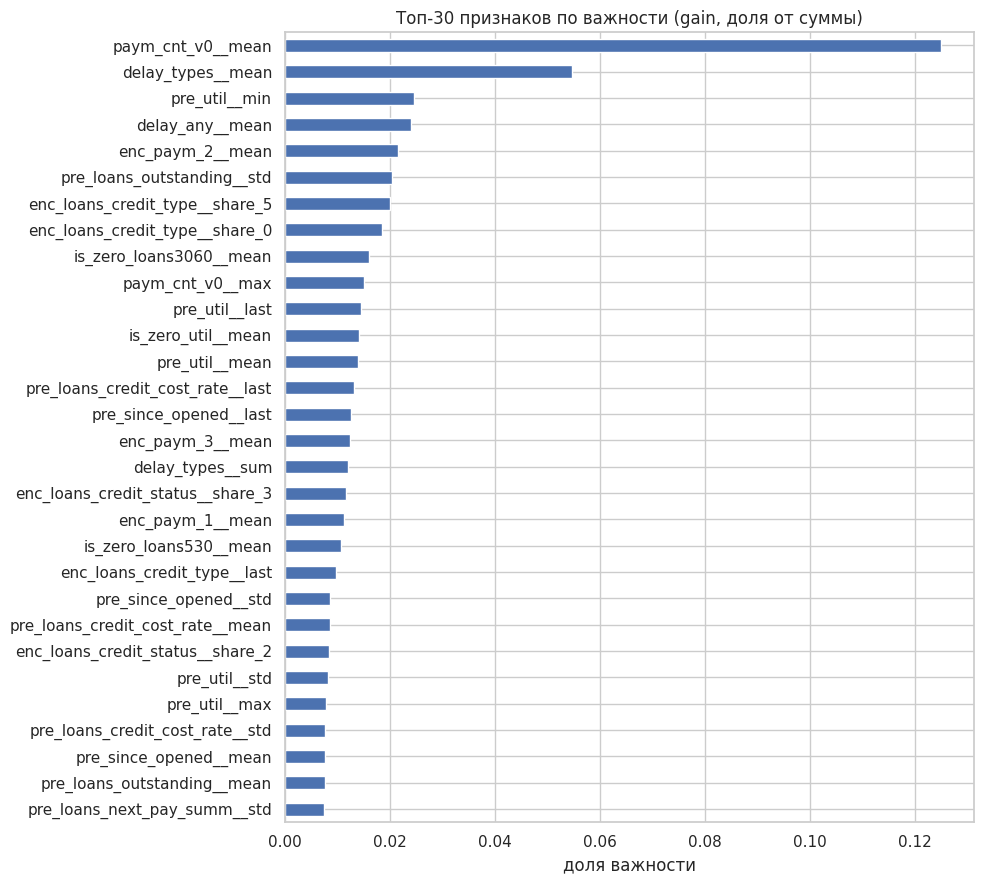

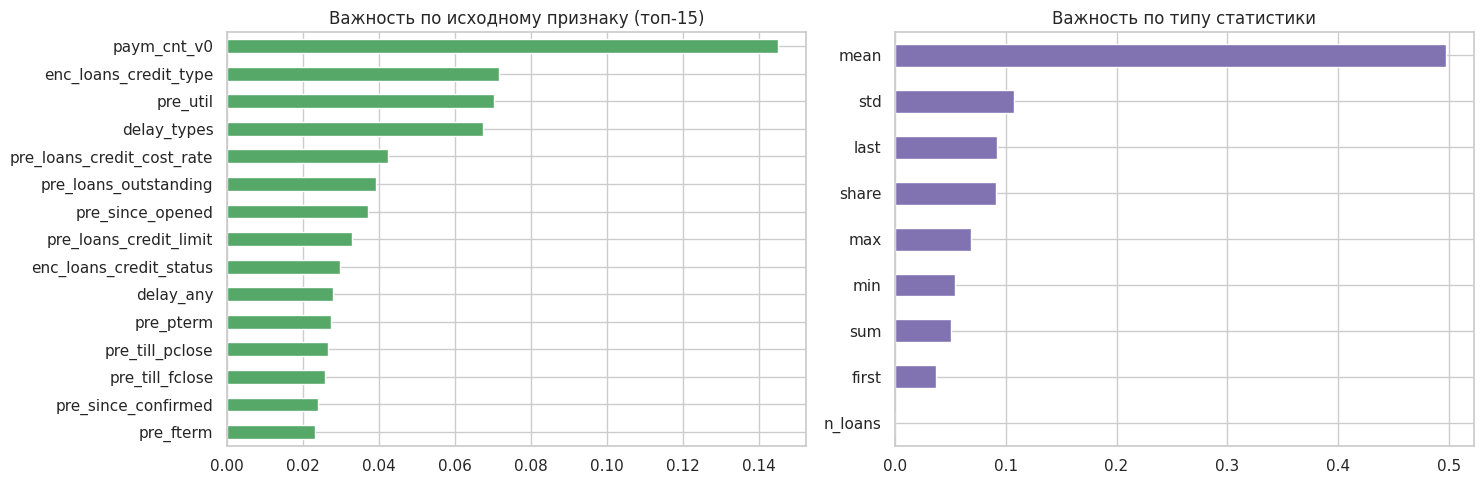

In [ ]:
imp = lgb_res["imp"].mean(axis=1)
imp = (imp / imp.sum()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
imp.head(30)[::-1].plot.barh(ax=ax, color="#4C72B0")
ax.set_title("Топ-30 признаков по важности (gain, доля от суммы)"); ax.set_xlabel("доля важности")
plt.tight_layout(); plt.show()

base_imp = imp.groupby(lambda s: s.split("__")[0]).sum().sort_values(ascending=False)

def stat_name(s):
    if "__" not in s:
        return s                       # n_loans и т.п.
    st = s.split("__")[-1]
    return "share" if st.startswith("share_") else st

stat_imp = imp.groupby(stat_name).sum().sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
base_imp.head(15)[::-1].plot.barh(ax=ax[0], color="#55A868"); ax[0].set_title("Важность по исходному признаку (топ-15)")
stat_imp.head(12)[::-1].plot.barh(ax=ax[1], color="#8172B2"); ax[1].set_title("Важность по типу статистики")
plt.tight_layout(); plt.show()

### 12.4 SHAP
SHAP показывает вклад каждого признака в конкретное предсказание. Считаю на 10 тысячах клиентов по модели из первого фолда.



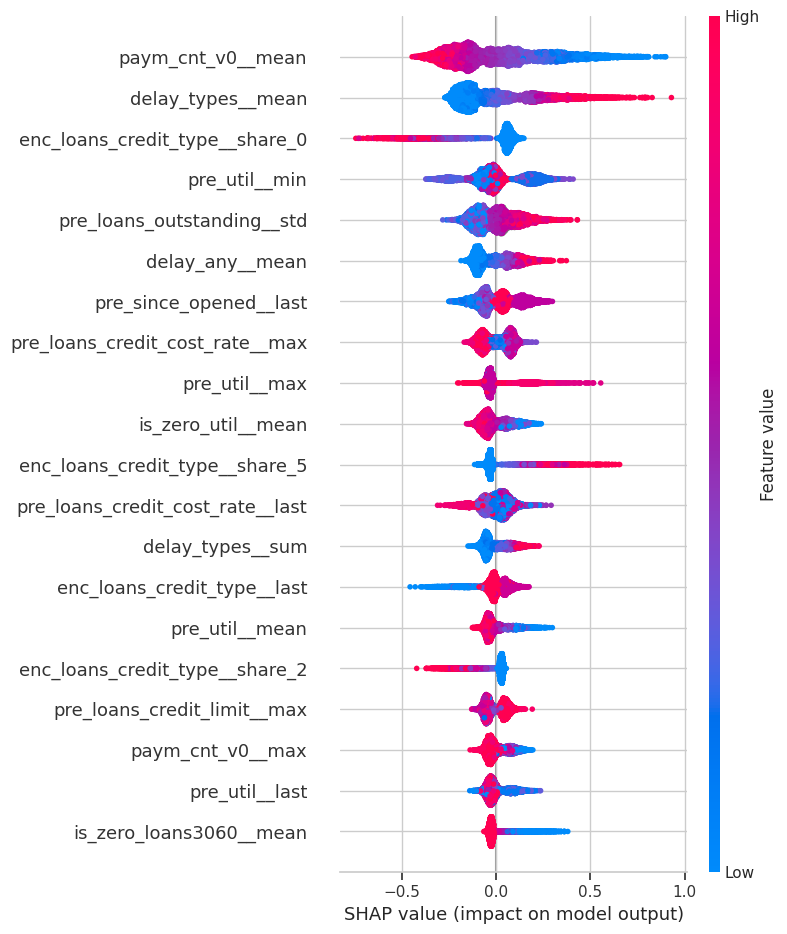

In [ ]:
if RUN_SHAP:
    try:
        import shap
        shap_idx = np.random.RandomState(SEED).choice(len(X_train), size=min(10_000, len(X_train)), replace=False)
        X_shap = X_train.iloc[shap_idx]
        sv = shap.TreeExplainer(lgb_res["models"][0]).shap_values(X_shap)
        if isinstance(sv, list):      # в старых версиях shap возвращается список [класс 0, класс 1]
            sv = sv[1]
        shap.summary_plot(sv, X_shap, max_display=20, show=True)
    except ImportError:
        print("shap не установлен: pip install shap")
    except Exception as e:
        print("SHAP пропущен из-за ошибки:", repr(e))

## 13. Submission

Беру предсказания для test и записываю в формат `sample_submission.csv`: первая колонка $id$, вторая — скор. Названия колонок беру прямо из шаблона, чтобы не ошибиться. В конце проверяю, что у каждого $id$ есть предсказание и в скорах нет `NaN`.


In [ ]:
sub = pd.read_csv(DATA_DIR / "sample_submission.csv")
id_col, score_col = sub.columns[0], sub.columns[1]

pred_s = pd.Series(final_test, index=X_test.index)
sub[score_col] = pred_s.reindex(sub[id_col]).to_numpy()

assert sub[score_col].notna().all(), "Для части id из sample_submission нет предсказаний"
assert sub[id_col].is_unique, "В sample_submission повторяются id"

sub.to_csv(SUBMISSION_PATH, index=False)
print(f"Модель: {final_name} | сохранено: {SUBMISSION_PATH}, форма {sub.shape}")
display(sub.head())
print(sub[score_col].describe().round(4).to_dict())

Модель: Blend (w_lgb=0.70) | сохранено: /content/drive/MyDrive/проекты ML/credit scoring original/submission.csv, форма (500000, 2)


,id,score
0,3000000,0.772811
1,3000001,0.866204
2,3000002,0.566186
3,3000003,0.726201
4,3000004,0.351161


{'count': 500000.0, 'mean': 0.5, 'std': 0.2868, 'min': 0.0, '25%': 0.2516, '50%': 0.5, '75%': 0.7474, 'max': 1.0}


## 14. Выводы
1. Разобрались со структурой данных: таргет на уровне клиента, признаки на уровне кредитов.
2. Проверили качество данных, посмотрели распределения, связь с таргетом, корреляции и сходство train с test.
3. Сжали кредитную историю в одну строку на клиента.
4. Сравнили логрег → LightGBM → CatBoost → бленд на одной и той же стратифицированной кросс-валидации. Оценили их по AUC, Gini, KS, PR AUC, lift и калибровке.
